                                         Actividad Umbral
Nombre:Franz Caballero


link word:https://github.com/FcCaba/Procesamiento-De-Imagenes/blob/unidad_1/Documentos%20word/otsu.docx

umbral con tecnica de isoda

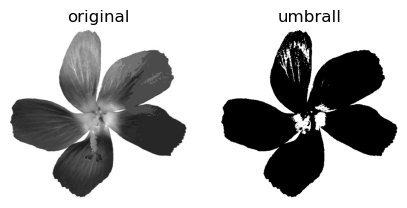

In [46]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def isodata(imagen):
    umbrall=128
    while True:
        grupo1=imagen[imagen<=umbrall]
        grupo2=imagen[imagen>=umbrall]
        
        medig1=np.mean(grupo1)
        medig2=np.mean(grupo2)
        umbrall_nuevo=(medig1+medig2)/2
        if abs(umbrall_nuevo-umbrall)<0.5:
            break
        umbrall=umbrall_nuevo
    return umbrall
imagen=cv2.imread("imagenes/original/flores.jpeg",0)
umbral_isodata=isodata(imagen)
_,imagen_isodata=cv2.threshold(imagen,umbral_isodata,255,cv2.THRESH_BINARY)
plt.figure(figsize=(5,10))
plt.subplot(1,2,1)
plt.title("original")
plt.axis("off")
plt.imshow(imagen,cmap="gray")

plt.subplot(1,2,2)
plt.title("umbrall")
plt.imshow(imagen_isodata,cmap="gray")
plt.axis("off")
plt.show()

umbral tecnica de 2 picos

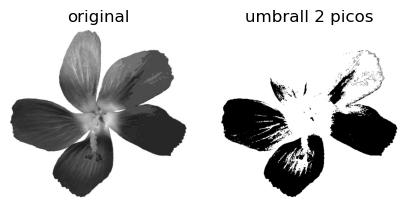

In [47]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def dos_picos(imagen):
    hist=cv2.calcHist([imagen],[0],None,[256],[0,256])
    pico=np.array(hist)
    pico=pico.flatten()
    pico_dif=np.diff(pico)
    primer_pico=np.argmax(pico_dif[:128])
    segundo_pico=np.argmax(pico_dif[128:])
    umbral_2picos=(primer_pico+segundo_pico)/2
    return umbral_2picos
imagen=cv2.imread("imagenes/original/flores.jpeg",0)
umbral_2picos=dos_picos(imagen)
_,imagen_2picos=cv2.threshold(imagen,umbral_2picos,255,cv2.THRESH_BINARY)
plt.figure(figsize=(5,10))
plt.subplot(1,2,1)
plt.title("original")
plt.axis("off")
plt.imshow(imagen,cmap="gray")

plt.subplot(1,2,2)
plt.title("umbrall 2 picos")
plt.imshow(imagen_2picos,cmap="gray")
plt.axis("off")
plt.show()

umbral metodo de otsu

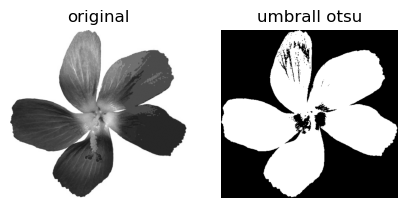

In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
imagen=cv2.imread("imagenes/original/flores.jpeg",0)


_,imagenOtsu=cv2.threshold(imagen,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
umbral_imagen=np.where(imagen>imagenOtsu,255,0).astype(np.uint8)
plt.figure(figsize=(5,10))
plt.subplot(1,2,1)
plt.title("original")
plt.axis("off")
plt.imshow(imagen,cmap="gray")

plt.subplot(1,2,2)
plt.title("umbrall otsu")
plt.imshow(umbral_imagen,cmap="gray")
plt.axis("off")
plt.show()

umbralizacion variable-particion de una imagen

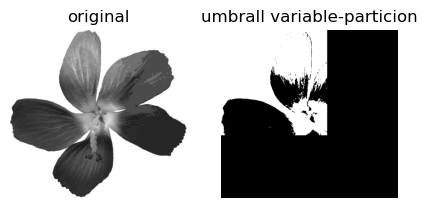

In [49]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def variable_umb_blok(imagen,tam_bloque,c):
    umbral_ima=np.zeros_like(imagen)
    for y in range(0,imagen.shape[0],tam_bloque):
        for x in range(0,imagen.shape[1],tam_bloque):
            bloque=imagen[y:y+tam_bloque,x:x+tam_bloque]
            bloque_media=np.mean(bloque)
            umbral_adap=bloque_media-c
            umbral_ima[y:y+tam_bloque,x:x+tam_bloque]=(bloque>umbral_adap)*255
            return umbral_ima
imagen=cv2.imread("imagenes/original/flores.jpeg",0)
tam_bloque=300
c=50
umbral_imagen_Adap=variable_umb_blok(imagen,tam_bloque,c)
plt.figure(figsize=(5,10))
plt.subplot(1,2,1)
plt.title("original")
plt.axis("off")
plt.imshow(imagen,cmap="gray")

plt.subplot(1,2,2)
plt.title("umbrall variable-particion")
plt.imshow(umbral_imagen_Adap,cmap="gray")
plt.axis("off")
plt.show()

umbral con desviacion

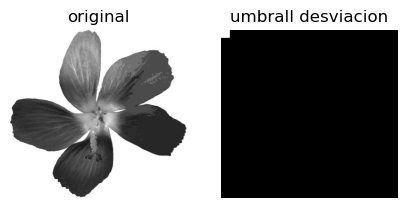

In [50]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def umbra_var2(imagen,tam_bloque,ajuste):
    umbral_ima=np.zeros_like(imagen)
    for y in range(0,imagen.shape[0],tam_bloque):
        for x in range(0,imagen.shape[1],tam_bloque):
            bloque=imagen[y:y+tam_bloque,x:x+tam_bloque]
            bloque_media=np.mean(bloque)
            des=np.std(bloque)
            umbral_adap=bloque_media-(ajuste*des)
            umbral_ima[y:y+tam_bloque,x:x+tam_bloque]=(bloque>umbral_adap)*255
            return umbral_ima

imagen=cv2.imread("imagenes/original/flores.jpeg",0)
tam_bloque=25
ajuste=50
umbral_imagen_Adap=variable_umb_blok(imagen,tam_bloque,ajuste)
plt.figure(figsize=(5,10))
plt.subplot(1,2,1)
plt.title("original")
plt.axis("off")
plt.imshow(imagen,cmap="gray")

plt.subplot(1,2,2)
plt.title("umbrall desviacion")
plt.imshow(umbral_imagen_Adap,cmap="gray")
plt.axis("off")
plt.show()

umbral adaptativa con ventana

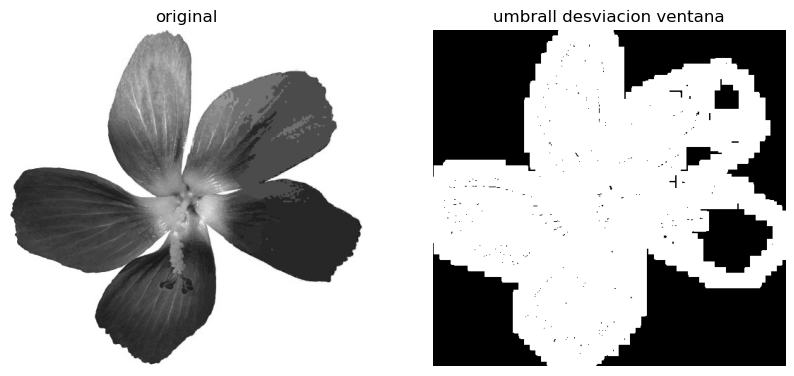

In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def ventana(imagen,ventana,factor):
    umbre_imagen=np.zeros_like(imagen)
    pad=ventana//2
    padd_img=cv2.copyMakeBorder(imagen,pad,pad,pad,pad,cv2.BORDER_REPLICATE)
    for y in range(imagen.shape[0]):
        for x in range(imagen.shape[1]):
            ventana1=padd_img[y:y+ventana,x:x+ventana]
            media=np.mean(ventana1)
            dis=np.std(ventana1)
            umbral=media-(factor*dis)
            umbre_imagen[y,x]=255 if imagen[y,x]>umbral else 0
    return umbre_imagen

imagen=cv2.imread("imagenes/original/flores.jpeg",0)
tam_bloque=15# siempre tiene que ser impar
ajuste=2
umbral_ventana=ventana(imagen,tam_bloque,ajuste)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("original")
plt.axis("off")
plt.imshow(imagen,cmap="gray")

plt.subplot(1,2,2)
plt.title("umbrall desviacion ventana")
plt.imshow(umbral_ventana,cmap="gray")
plt.axis("off")
plt.show()


ventana

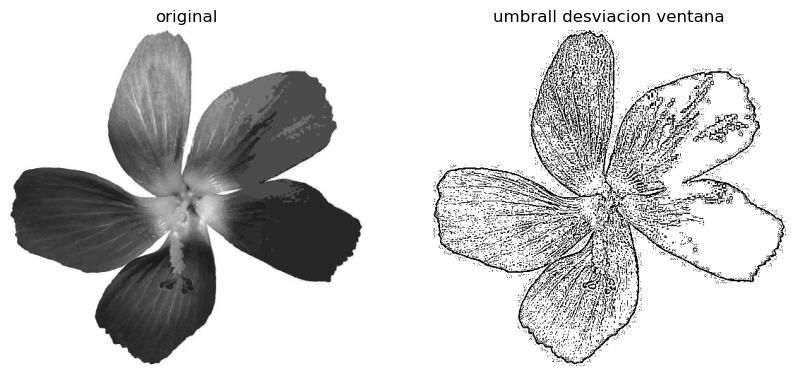

In [52]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen=cv2.imread("imagenes/original/flores.jpeg",0)
ventana=5
factor=2
imagen_umbr=cv2.adaptiveThreshold(imagen,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,ventana,factor)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("original")
plt.axis("off")
plt.imshow(imagen,cmap="gray")

plt.subplot(1,2,2)
plt.title("umbrall desviacion ventana")
plt.imshow(imagen_umbr,cmap="gray")
plt.axis("off")
plt.show()


Actividad.- investiga el metodo de otsu

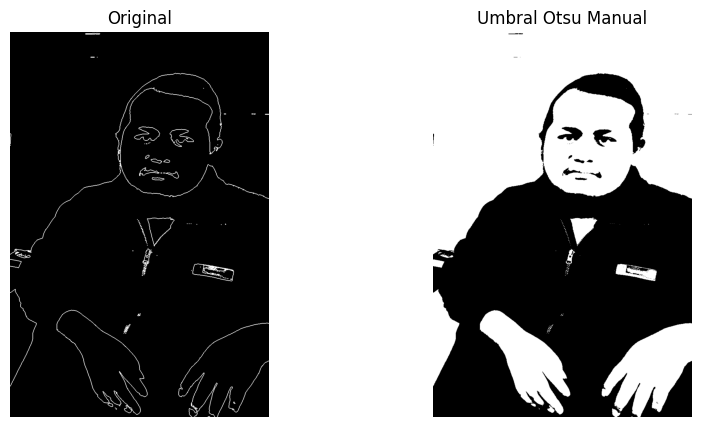

In [ ]:
import cv2
import numpy as np

import matplotlib.pyplot as plt

def metodo_otsu(imagen):
    histograma, _ = np.histogram(imagen, bins=256, range=(0, 256))
    probabilidad = histograma / np.sum(histograma)
    umbral_optimo = 0
    varianza_maxima = 0
    
    for umbral in range(256):
        probabilidad_fondo = np.sum(probabilidad[:umbral])
        probabilidad_objeto = np.sum(probabilidad[umbral:])
        
        media_fondo = np.sum(np.arange(umbral) * probabilidad[:umbral]) / probabilidad_fondo if probabilidad_fondo > 0 else 0
        media_objeto = np.sum(np.arange(umbral, 256) * probabilidad[umbral:]) / probabilidad_objeto if probabilidad_objeto > 0 else 0
        
        varianza_entre_clases = probabilidad_fondo * probabilidad_objeto * (media_fondo - media_objeto) ** 2
        
        if varianza_entre_clases > varianza_maxima:
            varianza_maxima = varianza_entre_clases
            umbral_optimo = umbral
    
    return umbral_optimo

umbral_otsu_manual = metodo_otsu(imagen)
_, imagen_otsu_manual = cv2.threshold(imagen, umbral_otsu_manual, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.axis("off")
plt.imshow(imagen, cmap="gray")

plt.subplot(1, 2, 2)
plt.title("Umbral Otsu Manual")
plt.axis("off")
plt.imshow(imagen_otsu_manual, cmap="gray")
plt.show()

In [ ]:
# Apply Canny edge detection
edges = cv2.Canny(imagen, 100, 200)

# Plot the original image and the edges
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.axis("off")
plt.imshow(imagen, cmap="gray")

plt.subplot(1, 2, 2)
plt.title("Edges")
plt.axis("off")
plt.imshow(edges, cmap="gray")
plt.show()